✅ Loaded 503 NIFTY-500 tickers.


Validating tickers:  30%|██▉       | 149/503 [00:27<00:59,  5.96it/s]ERROR:yfinance:HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: DUMMYSKFIN.NS"}}}
ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['DUMMYSKFIN.NS']: YFPricesMissingError('possibly delisted; no price data found  (period=5d) (Yahoo error = "No data found, symbol may be delisted")')
Validating tickers:  30%|██▉       | 150/503 [00:28<01:45,  3.33it/s]ERROR:yfinance:HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: DUMMYTATAM.NS"}}}
ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['DUMMYTATAM.NS']: YFPricesMissingError('possibly delisted; no price data found  (period=5d) (Yahoo error = "No data found, symbol may be delisted")')
Validating tickers:  30%|███       | 151/503 [00:28<02:20,  2.51it/s]ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['DUMMYDBRLT.NS']: YFPricesMissingError

✅ 500 valid tickers out of 503 checked.
First 10 valid tickers: ['360ONE.NS', '3MINDIA.NS', 'ABB.NS', 'ACC.NS', 'ACMESOLAR.NS', 'AIAENG.NS', 'APLAPOLLO.NS', 'AUBANK.NS', 'AWL.NS', 'AADHARHFC.NS']


Fetching stock data: 100%|██████████| 10/10 [00:32<00:00,  3.27s/it]


✅ Successfully fetched 500 tickers. Failed: 0
✅ Feature dataset shape: (113369, 14)
✅ Model performance: {'accuracy': 0.5417658992678839, 'precision': 0.5367057371992597, 'recall': 0.4701008645533141, 'f1': 0.501200192030725, 'roc_auc': np.float64(0.5554881295161141)}
✅ Scored 500 tickers.

Enter total investment amount (e.g. 100000): 6789500

Top 15 stocks:
            ticker     score   last_close
0   AEGISVOPAK.NS  0.693333   280.500000
1     AEGISLOG.NS  0.693333   794.000000
2     GODREJCP.NS  0.680000  1118.199951
3          NCC.NS  0.626667   209.619995
4       INDIGO.NS  0.626667  5702.000000
5     GRANULES.NS  0.626667   556.450012
6   CARBORUNIV.NS  0.626667   896.799988
7         GPIL.NS  0.613333   262.000000
8     SAPPHIRE.NS  0.600000   287.450012
9        RITES.NS  0.593333   247.190002
10  ADANIGREEN.NS  0.586667  1034.699951
11   FINCABLES.NS  0.586667   787.799988
12        TTML.NS  0.580000    54.799999
13        MRPL.NS  0.573333   146.110001
14  APOLLOTYRE.NS  0.56

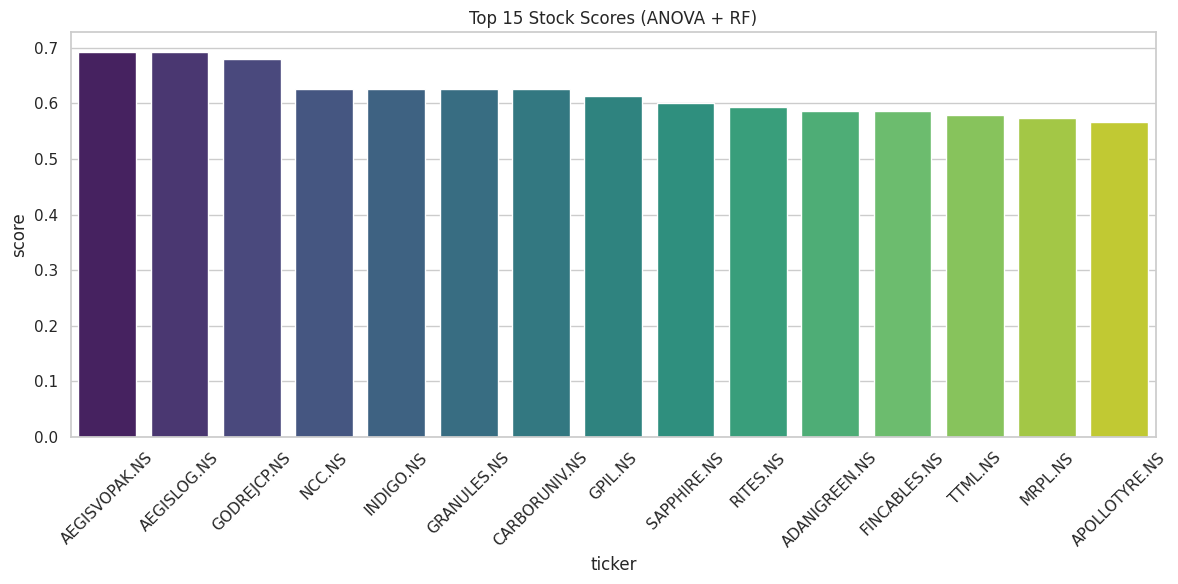

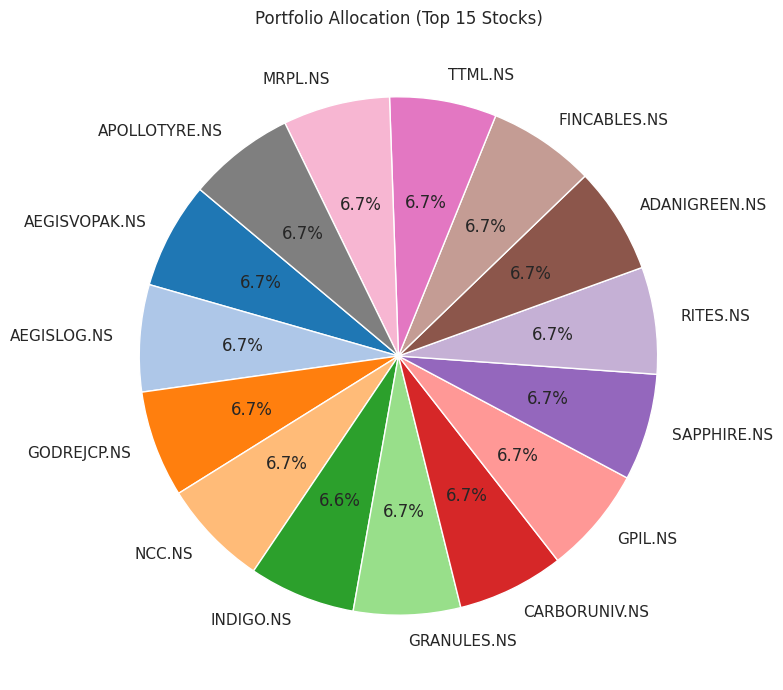

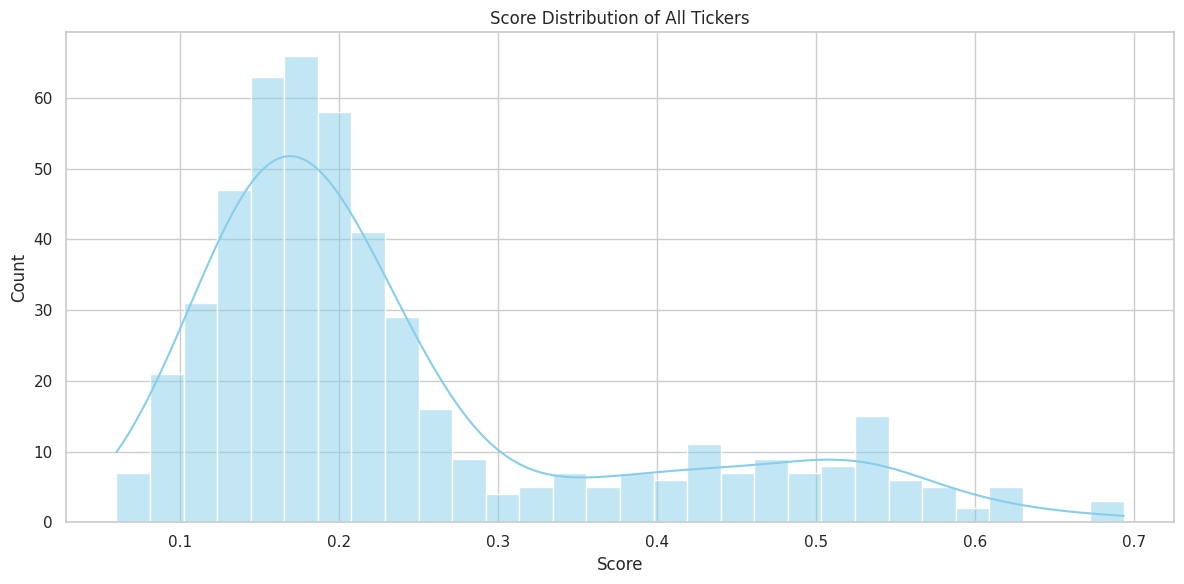

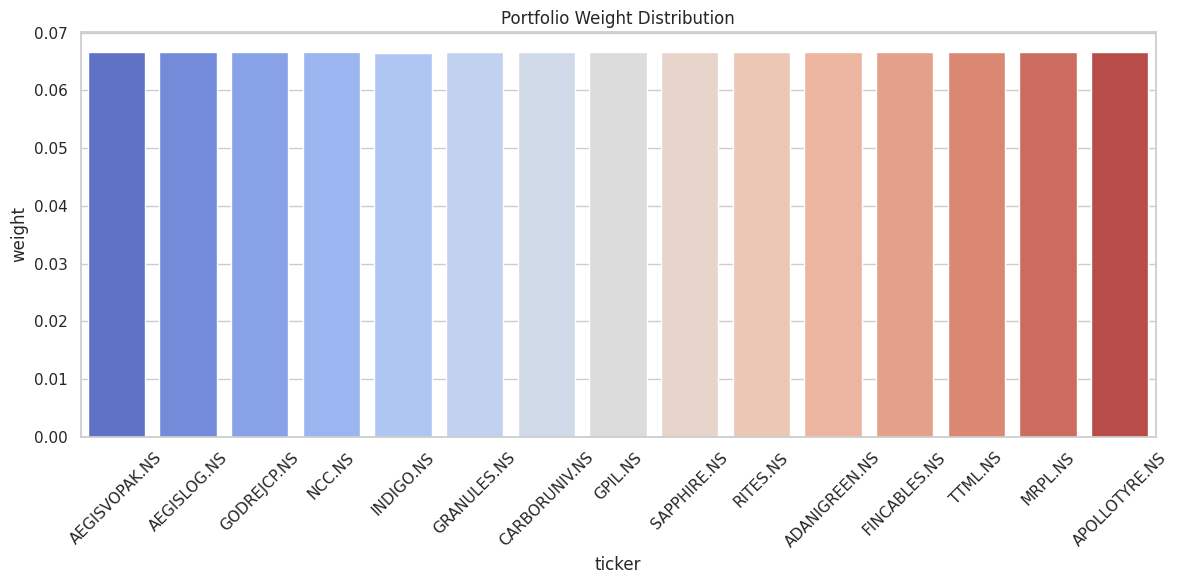

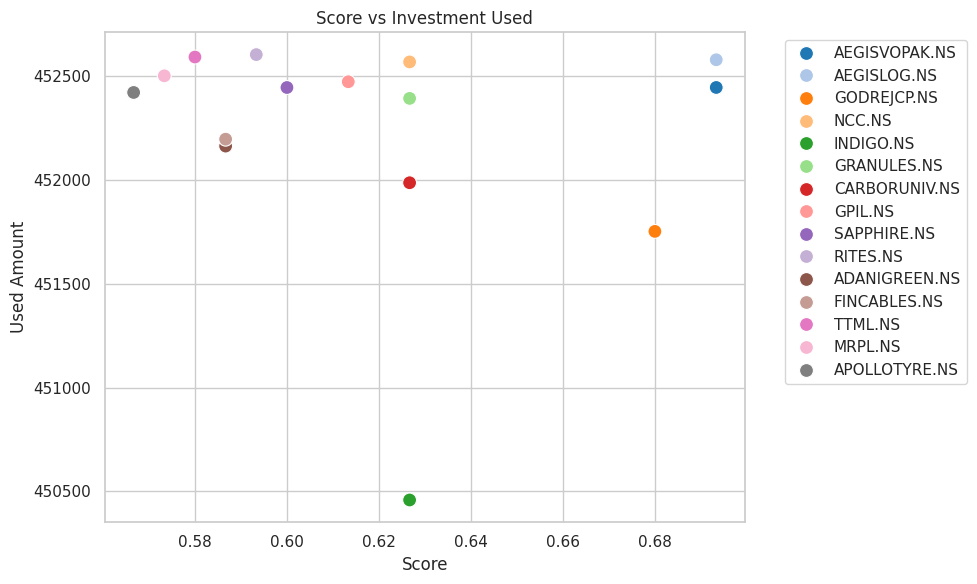

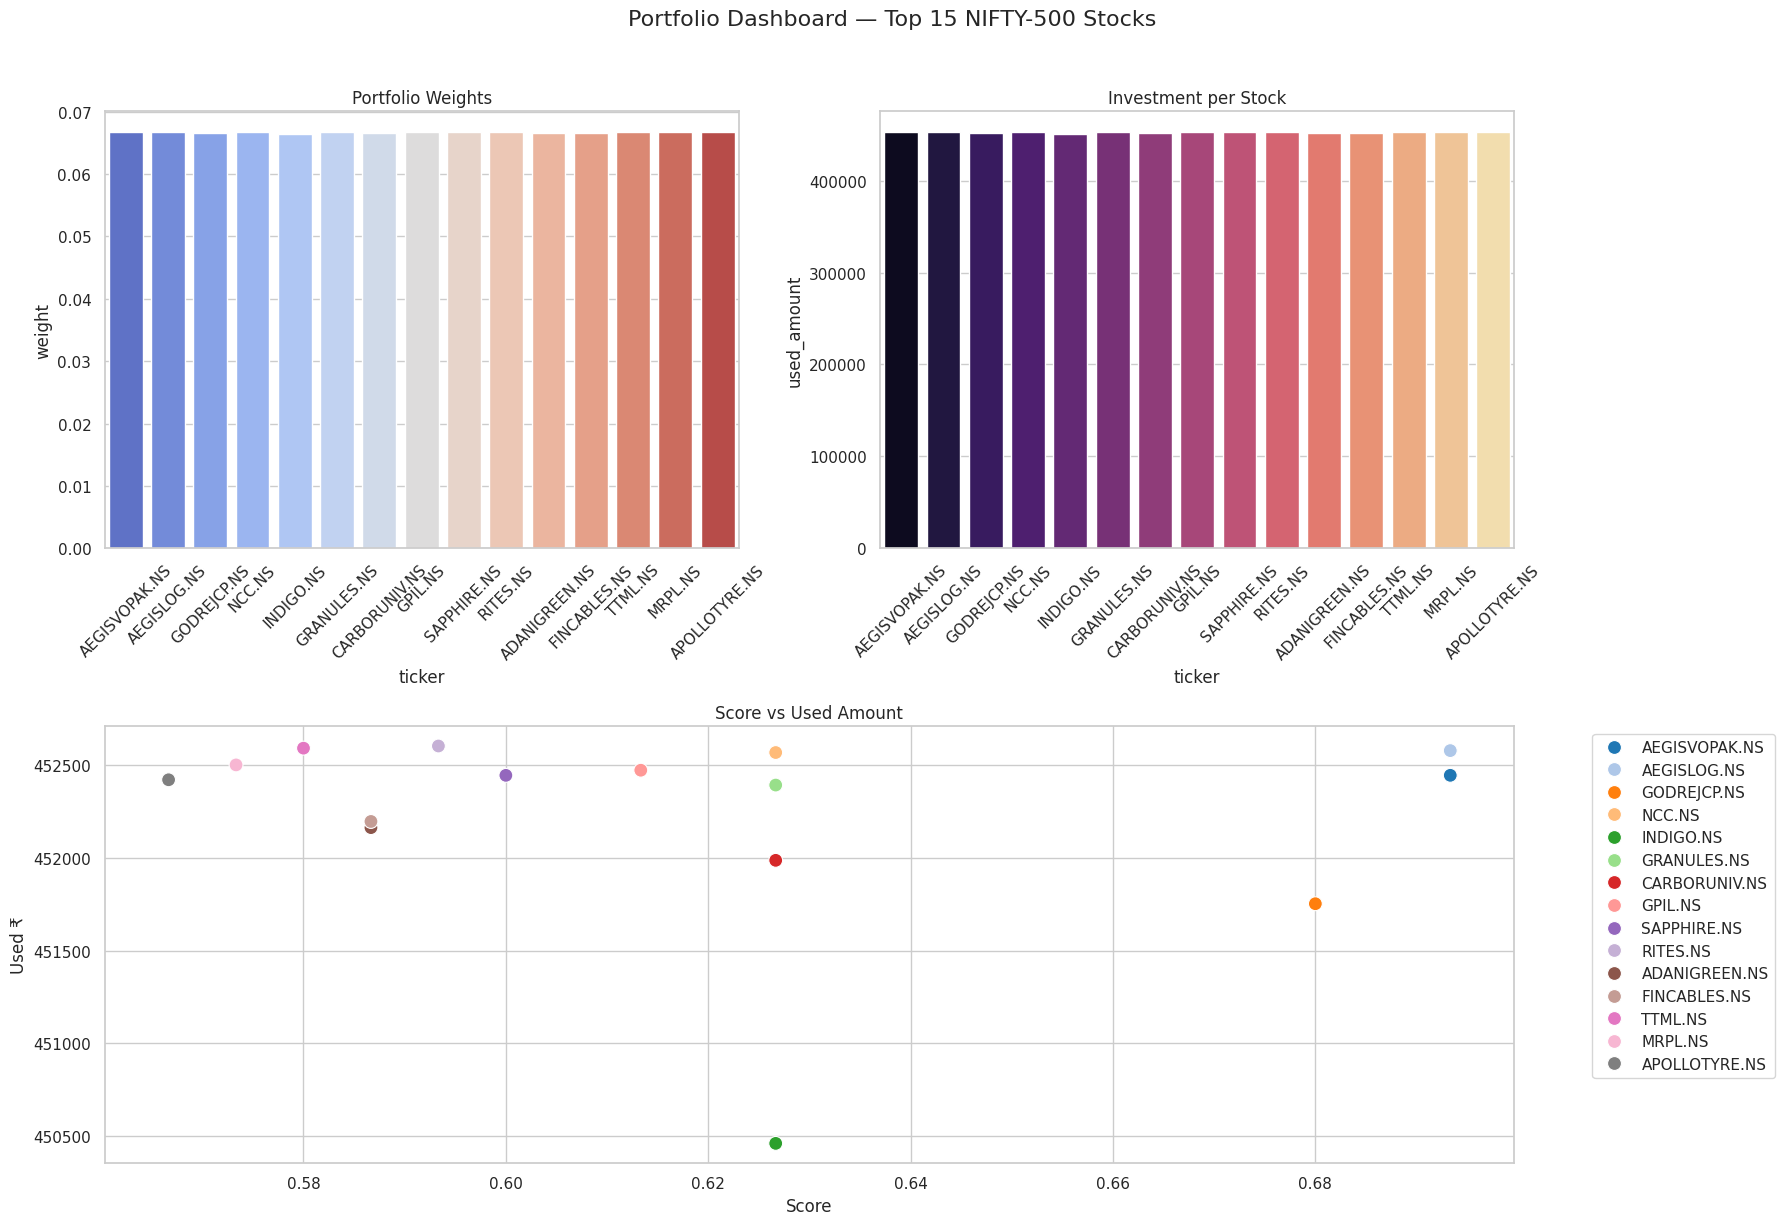


✅ All done! Dashboard saved to outputs/portfolio_dashboard.png


In [2]:
# ================================================================
# 📊 NIFTY-500 AI Portfolio Builder (ANOVA + RandomForest version)
# ================================================================
# ✅ Features:
#   - Fetches all NIFTY-500 tickers from NSE
#   - Validates on Yahoo Finance
#   - Builds features on 1-year data
#   - Trains ANOVA+RandomForest model
#   - Scores all stocks
#   - Creates Top-15 portfolio + visualizations
# ================================================================

import os, math, random, warnings
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from datetime import datetime
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

# --- Setup ---
warnings.filterwarnings("ignore")
tqdm.pandas()
sns.set(style="whitegrid")
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# ================================================================
# 1️⃣ Fetch and validate tickers
# ================================================================
def get_nifty500_tickers():
    url = "https://archives.nseindia.com/content/indices/ind_nifty500list.csv"
    try:
        df = pd.read_csv(url)
        tickers = [t.strip() + ".NS" for t in df["Symbol"].dropna().unique().tolist()]
        print(f"✅ Loaded {len(tickers)} NIFTY-500 tickers.")
        return tickers
    except Exception as e:
        print("⚠️ Could not fetch NSE list:", e)
        return []

def validate_tickers(tickers):
    valid = []
    for t in tqdm(tickers, desc="Validating tickers"):
        try:
            data = yf.download(t, period="5d", progress=False)
            if not data.empty:
                valid.append(t)
        except:
            pass
    print(f"✅ {len(valid)} valid tickers out of {len(tickers)} checked.")
    return valid

TICKERS = get_nifty500_tickers()
VALID_TICKERS = validate_tickers(TICKERS)
if len(VALID_TICKERS) == 0:
    VALID_TICKERS = [
        "RELIANCE.NS","TCS.NS","INFY.NS","HDFCBANK.NS","ICICIBANK.NS",
        "SBIN.NS","ITC.NS","BHARTIARTL.NS","KOTAKBANK.NS","LT.NS",
        "HINDUNILVR.NS","AXISBANK.NS","BAJFINANCE.NS","ASIANPAINT.NS",
        "MARUTI.NS","SUNPHARMA.NS","ULTRACEMCO.NS","WIPRO.NS","TITAN.NS","HCLTECH.NS"
    ]
    print("⚠️ Using fallback 20 reliable tickers.")
print("First 10 valid tickers:", VALID_TICKERS[:10])

# ================================================================
# 2️⃣ Download price data (1-year)
# ================================================================
def fetch_price_data(tickers, period="1y", interval="1d"):
    all_data, failed = {}, []
    batch_size = 50
    for i in tqdm(range(0, len(tickers), batch_size), desc="Fetching stock data"):
        batch = tickers[i:i+batch_size]
        try:
            data = yf.download(batch, period=period, interval=interval, group_by='ticker', progress=False)
            for t in batch:
                try:
                    df = data[t] if t in data else None
                    if df is not None and not df.empty:
                        df = df.reset_index()
                        df.columns = [c.lower() for c in df.columns]
                        df["ticker"] = t
                        all_data[t] = df
                    else:
                        failed.append(t)
                except Exception:
                    failed.append(t)
        except Exception:
            failed.extend(batch)
    print(f"✅ Successfully fetched {len(all_data)} tickers. Failed: {len(failed)}")
    return all_data

price_data = fetch_price_data(VALID_TICKERS, period="1y")

# ================================================================
# 3️⃣ Feature Engineering
# ================================================================
def build_features(df):
    df = df.copy()
    df["ret_1d"] = df["close"].pct_change()
    df["ret_5d"] = df["close"].pct_change(5)
    df["ma_5"] = df["close"].rolling(5).mean()
    df["ma_20"] = df["close"].rolling(20).mean()
    df["vol_5d"] = df["close"].rolling(5).std()
    df["rsi"] = 100 - (100 / (1 + (df["ret_1d"].rolling(14)
                   .apply(lambda x: (x[x>0].sum() / -x[x<0].sum()) if -x[x<0].sum()!=0 else 0))))
    df["target"] = (df["close"].shift(-5) > df["close"]).astype(int)
    return df.dropna().reset_index(drop=True)

def build_feature_dataset(data_dict):
    dfs=[]
    for t,df in data_dict.items():
        f=build_features(df)
        if not f.empty:
            dfs.append(f)
    return pd.concat(dfs,ignore_index=True)

full_df = build_feature_dataset(price_data)
print("✅ Feature dataset shape:", full_df.shape)

# ================================================================
# 4️⃣ Train ANOVA + RandomForest
# ================================================================
def train_anova_rf(df):
    feats = ['ret_1d','ret_5d','ma_5','ma_20','vol_5d','rsi']
    X = df[feats].fillna(0).values
    y = df["target"].values
    X_train,X_val,y_train,y_val = train_test_split(X,y,test_size=0.2,random_state=SEED)

    scaler = StandardScaler().fit(X_train)
    X_train_s = scaler.transform(X_train)
    X_val_s = scaler.transform(X_val)

    selector = SelectKBest(f_classif, k=min(5, X_train_s.shape[1]))
    X_train_sel = selector.fit_transform(X_train_s, y_train)
    X_val_sel = selector.transform(X_val_s)

    rf = RandomForestClassifier(n_estimators=150, random_state=SEED)
    rf.fit(X_train_sel, y_train)

    preds = rf.predict(X_val_sel)
    prob = rf.predict_proba(X_val_sel)[:,1]

    metrics = {
        "accuracy": accuracy_score(y_val,preds),
        "precision": precision_score(y_val,preds),
        "recall": recall_score(y_val,preds),
        "f1": f1_score(y_val,preds),
        "roc_auc": roc_auc_score(y_val,prob)
    }
    print("✅ Model performance:", metrics)
    return rf, feats, scaler, selector, metrics

model, feats, scaler, selector, metrics = train_anova_rf(full_df)

# ================================================================
# 5️⃣ Score all stocks
# ================================================================
def score_all(df, model, feats, scaler, selector):
    X = df[feats].fillna(0).values
    X_scaled = scaler.transform(X)
    X_sel = selector.transform(X_scaled)
    df["score"] = model.predict_proba(X_sel)[:,1]
    latest = df.sort_values('date').groupby('ticker').tail(1)
    latest = latest[['ticker','score','close']].rename(columns={'close':'last_close'})
    latest = latest.sort_values('score',ascending=False).reset_index(drop=True)
    print(f"✅ Scored {len(latest)} tickers.")
    return latest

scores = score_all(full_df, model, feats, scaler, selector)

# ================================================================
# 6️⃣ Portfolio Allocation
# ================================================================
def allocate_portfolio(total, df):
    n = len(df)
    equal_amt = total/n
    alloc = []
    for _,r in df.iterrows():
        qty = math.floor(equal_amt / r['last_close'])
        used = qty * r['last_close']
        alloc.append([r['ticker'], r['score'], r['last_close'], qty, used])
    port = pd.DataFrame(alloc, columns=['ticker','score','last_close','quantity','used_amount'])
    port['weight'] = port['used_amount']/port['used_amount'].sum()
    return port

TOP_K = 15
top15 = scores.head(TOP_K)
os.makedirs("outputs", exist_ok=True)
amount = float(input("\nEnter total investment amount (e.g. 100000): "))
portfolio = allocate_portfolio(amount, top15)
used = portfolio['used_amount'].sum()
left = amount - used

print("\nTop 15 stocks:\n", top15)
print("\nPortfolio allocation:\n", portfolio)
print(f"\nTotal: ₹{amount:.2f}, Used: ₹{used:.2f}, Leftover: ₹{left:.2f}")

portfolio.to_csv("outputs/top15_allocation.csv", index=False)
scores.to_csv("outputs/scored_all_tickers.csv", index=False)
print("📁 Saved: outputs/top15_allocation.csv & outputs/scored_all_tickers.csv")

# ================================================================
# 7️⃣ Visualizations
# ================================================================
plt.figure(figsize=(12,6))
sns.barplot(x='ticker', y='score', data=top15, palette="viridis")
plt.title("Top 15 Stock Scores (ANOVA + RF)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,8))
plt.pie(portfolio['used_amount'], labels=portfolio['ticker'], autopct='%1.1f%%',
        startangle=140, colors=sns.color_palette("tab20", TOP_K))
plt.title("Portfolio Allocation (Top 15 Stocks)")
plt.tight_layout()
plt.show()

plt.figure(figsize=(12,6))
sns.histplot(scores['score'], bins=30, kde=True, color='skyblue')
plt.title("Score Distribution of All Tickers")
plt.xlabel("Score")
plt.tight_layout()
plt.show()

plt.figure(figsize=(12,6))
sns.barplot(x='ticker', y='weight', data=portfolio, palette="coolwarm")
plt.title("Portfolio Weight Distribution")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,6))
sns.scatterplot(x='score', y='used_amount', data=portfolio, hue='ticker', s=100, palette="tab20")
plt.title("Score vs Investment Used")
plt.xlabel("Score")
plt.ylabel("Used Amount")
plt.legend(bbox_to_anchor=(1.05,1), loc='upper left')
plt.tight_layout()
plt.show()

plt.figure(figsize=(18,12))
plt.subplot(2,2,1)
sns.barplot(x='ticker', y='weight', data=portfolio, palette="coolwarm")
plt.title("Portfolio Weights")
plt.xticks(rotation=45)

plt.subplot(2,2,2)
sns.barplot(x='ticker', y='used_amount', data=portfolio, palette="magma")
plt.title("Investment per Stock")
plt.xticks(rotation=45)

plt.subplot(2,1,2)
sns.scatterplot(x='score', y='used_amount', data=portfolio, hue='ticker', s=100, palette="tab20")
plt.title("Score vs Used Amount")
plt.xlabel("Score")
plt.ylabel("Used ₹")
plt.legend(bbox_to_anchor=(1.05,1), loc='upper left')
plt.suptitle("Portfolio Dashboard — Top 15 NIFTY-500 Stocks", fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig("outputs/portfolio_dashboard.png", dpi=300, bbox_inches='tight')
plt.show()

print("\n✅ All done! Dashboard saved to outputs/portfolio_dashboard.png")
